# MAST: Distribution of Number of Failures per Trace by Task/Type

This notebook plots, for each **task/type** (MAS framework), how many traces have 0, 1, 2, 3, ... labeled failures.

**Data source:** We use the **MAD dataset** ([Hugging Face](https://huggingface.co/datasets/mcemri/MAD)) when available. Each record has `mast_annotation`: a dict of failure dimensions with **numeric 0/1** (1 = that failure type present). We count the number of dimensions with value 1 as the number of failures per trace. Task/type comes from `mas_name` (e.g. AppWorld, AG2, HyperAgent, ChatDev).

In [1]:
import json
from pathlib import Path
from typing import Optional, Tuple
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

## 1. Load MAD dataset and compute failure counts per trace

MAD records have `mast_annotation`: keys are failure dimensions, values are **0 or 1**. We count how many dimensions are 1 per trace. Task/type = `mas_name` (e.g. AppWorld, AG2, ChatDev).

In [2]:
# Path to MAD dataset: MAST-local (download via scripts/0_download_mad.py)
MAST_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MAD_PATHS = [
    MAST_ROOT / "data" / "raw" / "MAD_full_dataset.json",
    Path("data/raw/MAD_full_dataset.json").resolve(),
    Path.cwd() / "data/raw/MAD_full_dataset.json",
]
MAD_PATH = None
for p in MAD_PATHS:
    if p.resolve().exists():
        MAD_PATH = p.resolve()
        break
if MAD_PATH is None:
    raise FileNotFoundError(
        f"MAD dataset not found. Tried: {MAD_PATHS}. "
        "Run from MAST repo: python scripts/0_download_mad.py  (downloads from HuggingFace mcemri/MAD)."
    )

def n_failures_from_mast_annotation(ann):
    """Count failures: number of mast_annotation dimensions with value 1 (0/1 encoding)."""
    if not ann:
        return 0
    return sum(1 for v in ann.values() if str(v).isdigit() and int(v) == 1)

with open(MAD_PATH, "r") as f:
    mad_data = json.load(f)

rows = []
for r in mad_data:
    ann = r.get("mast_annotation") or {}
    n_fail = n_failures_from_mast_annotation(ann)
    mas = r.get("mas_name", "UNKNOWN")
    rows.append({"task_type_top": mas, "trace_id": r.get("trace_id", ""), "n_failures": n_fail})

df = pd.DataFrame(rows)
task_types = df["task_type_top"].unique().tolist()
print(f"Loaded {len(df)} traces from MAD: {MAD_PATH.name}")
print(df.groupby("task_type_top").agg(count=("trace_id", "count"), failures_sum=("n_failures", "sum")).to_string())
df.head(10)

Loaded 1242 traces from MAD: a182daadb8ded015efc889db8bde29e5e4dd478e0dcc5516f6727a1bbc43eaec
               count  failures_sum
task_type_top                     
AG2              597          1674
AppWorld          30            37
ChatDev          130           281
HyperAgent        30            37
Magentic         195           473
MetaGPT          230           525
OpenManus         30            37


,task_type_top,trace_id,n_failures
0,ChatDev,0,0
1,ChatDev,1,0
2,ChatDev,2,0
3,ChatDev,3,2
4,ChatDev,4,0
5,ChatDev,5,3
6,ChatDev,6,1
7,ChatDev,7,2
8,ChatDev,8,9
9,ChatDev,9,0


## 2. Distribution of number of failures per trace (one plot per task/type)

For each task/type we plot how many traces have 0, 1, 2, 3, ... labeled failures (e.g. "In HyperAgent, how many traces have 1 failure? 2 failures? …").

## 2b. Proportion of traces with 0, 1, 2, ... failures (e.g. “what fraction of traces have exactly k failures?”)

For each task/type we can also plot the **proportion** (or percentage) of traces that have 0, 1, 2, 3, … labeled failures.

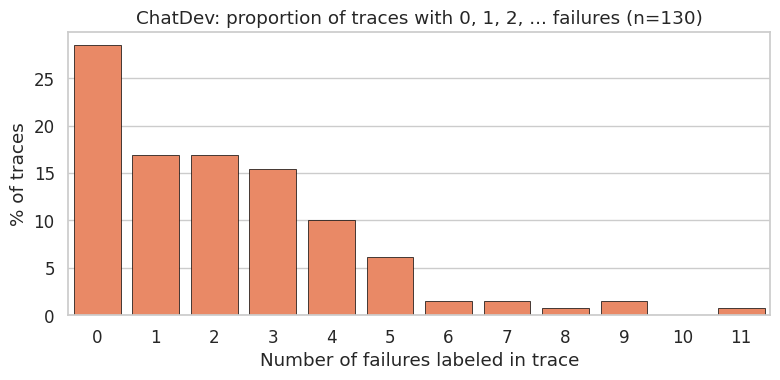

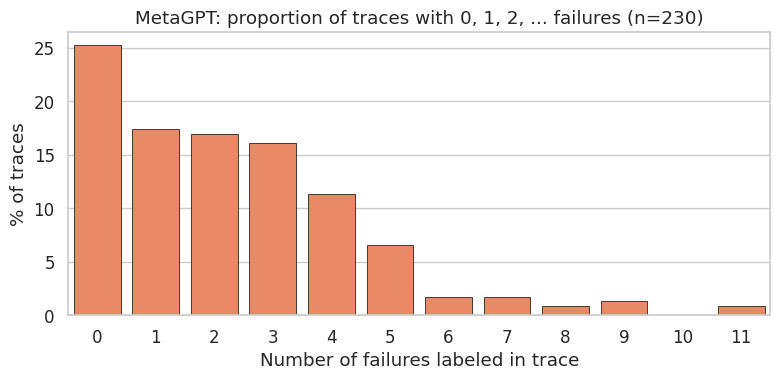

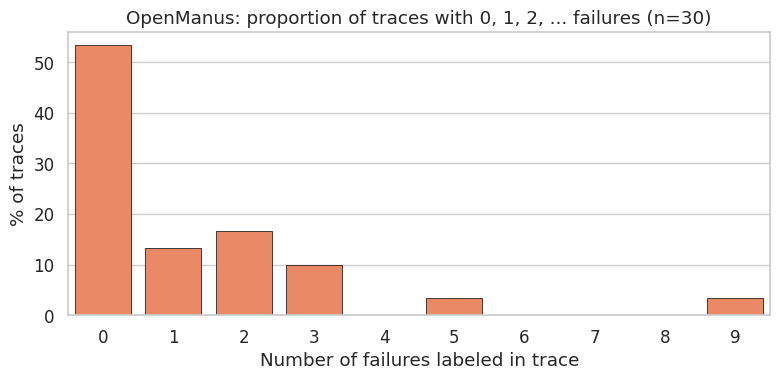

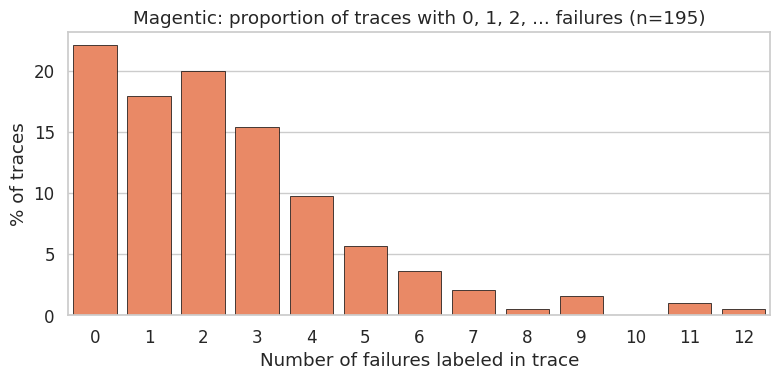

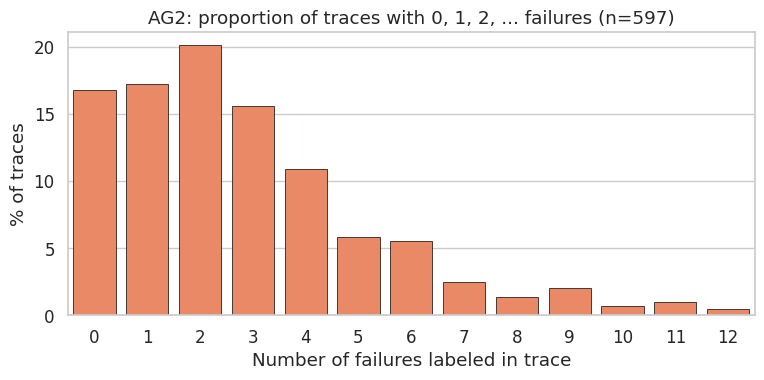

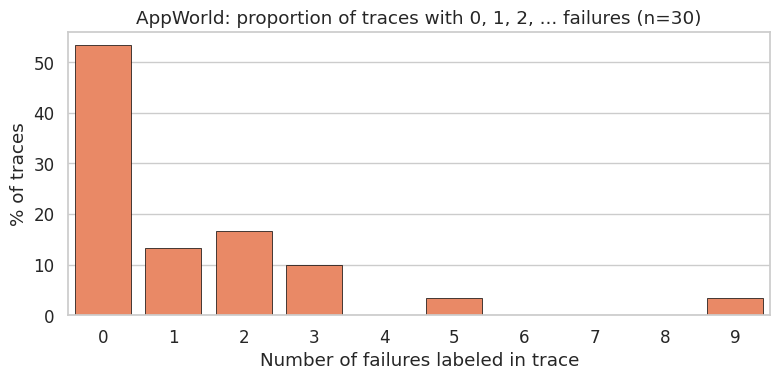

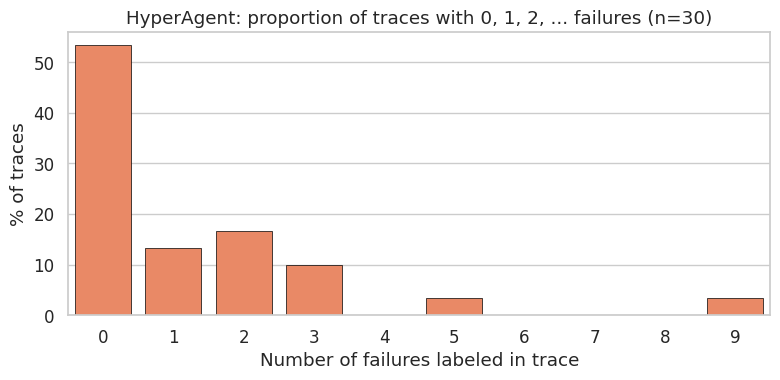

In [3]:
# Proportion (percentage) of traces with k failures, per task/type
for task in task_types:
    subset = df[df["task_type_top"] == task]
    n = len(subset)
    if n == 0:
        continue
    counts = subset["n_failures"].value_counts().sort_index()
    max_k = int(counts.index.max()) if len(counts) else 0
    props = (counts / n * 100).reindex(range(max_k + 1), fill_value=0).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=props.index.astype(int), y=props.values, color="coral", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Number of failures labeled in trace")
    ax.set_ylabel("% of traces")
    ax.set_title(f"{task}: proportion of traces with 0, 1, 2, ... failures (n={n})")
    plt.tight_layout()
    plt.show()

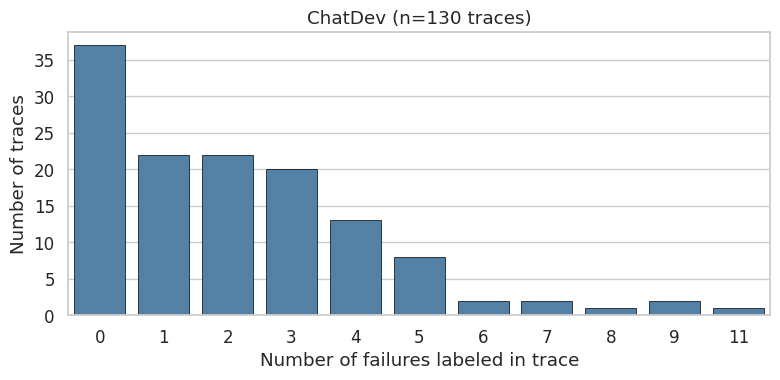

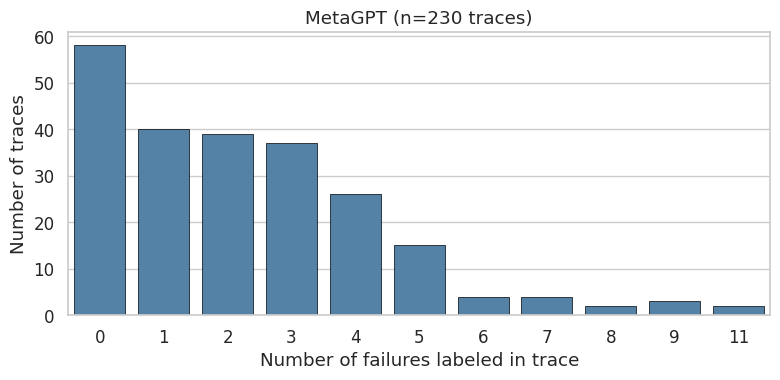

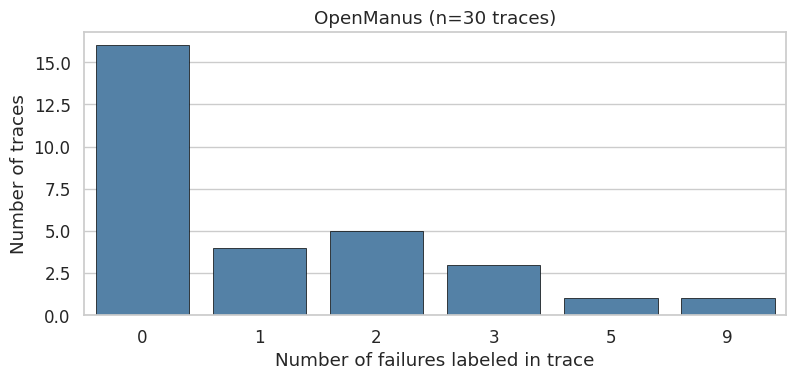

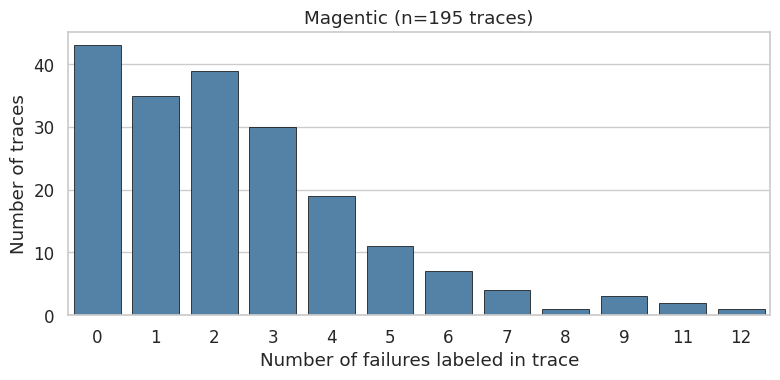

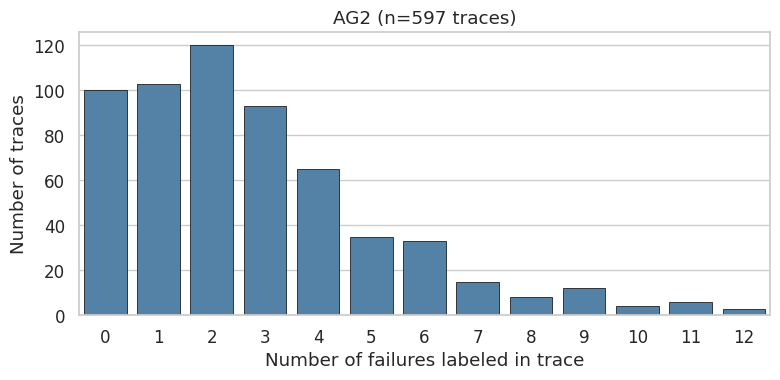

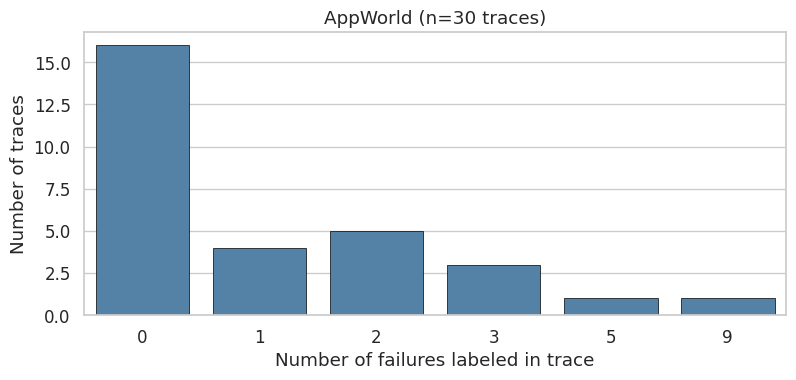

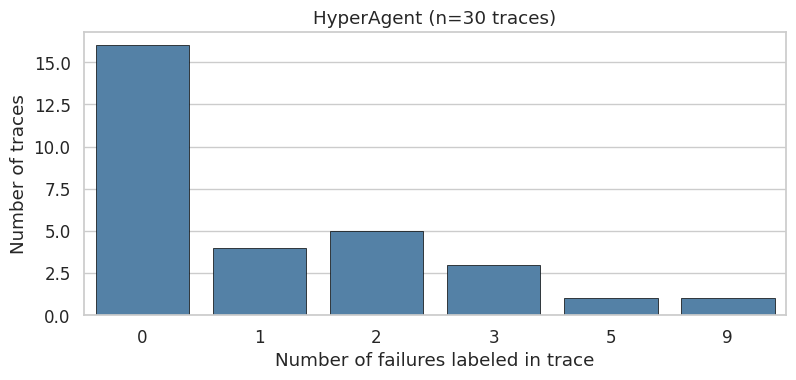

In [4]:
# One figure per task/type (count of traces with 0, 1, 2, ... failures)
for task in task_types:
    subset = df[df["task_type_top"] == task]
    counts = subset["n_failures"].value_counts().sort_index()
    
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=counts.index.astype(int), y=counts.values, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Number of failures labeled in trace")
    ax.set_ylabel("Number of traces")
    ax.set_title(f"{task} (n={len(subset)} traces)")
    plt.tight_layout()
    plt.show()

## 4. Combined overview: all task/types in one figure (facets)

Seaborn `displot` or a grid of bar plots to compare distributions across task/types.

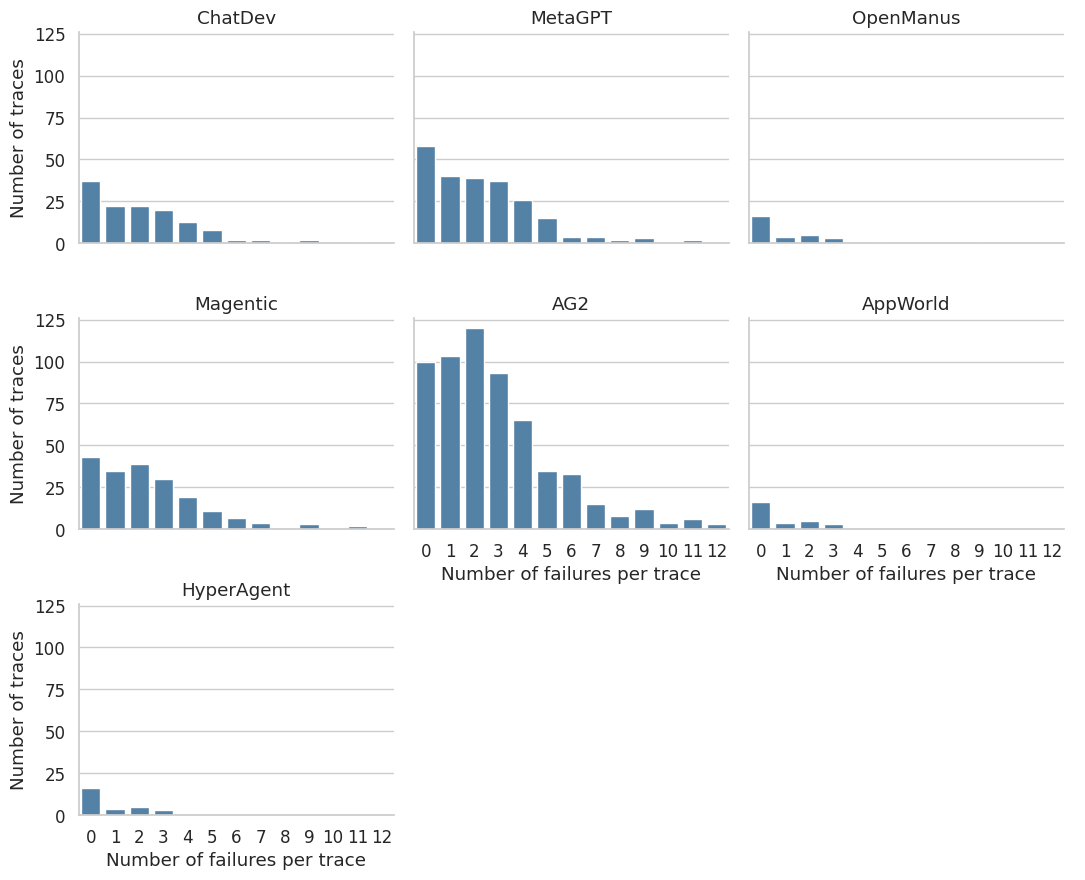

In [6]:
if len(df) > 0:
    # One facet per top-level task type (HyperAgent, AG2)
    valid = df[df["task_type_top"].notna()]
    if len(valid) > 0:
        g = sns.catplot(
            data=valid, x="n_failures", col="task_type_top", col_wrap=3, kind="count",
            height=3, aspect=1.2, color="steelblue"
        )
        g.set_axis_labels("Number of failures per trace", "Number of traces")
        g.set_titles("{col_name}")
        plt.tight_layout()
        plt.show()
    else:
        print("No data to plot.")
else:
    print("No data to plot.")